In [ ]:
!pip install -q langchain-chroma langchain_community langchain-huggingface sentence_transformers langgraph langchain-google-genai  rank_bm25 pydantic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 3

In [ ]:
from google.colab import userdata
from google.colab import userdata

In [ ]:
import os
import regex
import json
from IPython.display import Markdown
from sqlalchemy import create_engine
import pandas as pd

from langchain_core.documents import Document
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain_chroma import Chroma
from langchain.chat_models import init_chat_model
from langchain_community.retrievers import BM25Retriever

In [ ]:
# Env vars
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/cs431_data/outputs_processed/transcripts"
video_path = "/content/drive/MyDrive/cs431_data/"

In [ ]:
video_paths = set()
for root, dirs, files in os.walk(video_path):
    for file in files:
      if file.endswith(".mp4"):
        video_paths.add(os.path.join(video_path, file))
print(len(video_paths))

55


In [ ]:
for i in video_paths:
  print(i)

/content/drive/MyDrive/cs431_data/[CS431 - Chương 9] Part 1_1_ Giới thiệu bài toán Dịch máy.mp4
/content/drive/MyDrive/cs431_data/[CS431 - Chương 10] Part 3_ Cơ chế Self-Attention.mp4
/content/drive/MyDrive/cs431_data/[CS431 - Chương 9] Part 2_2_ Cơ chế Attention trong Sequence-to-Sequence.mp4
/content/drive/MyDrive/cs431_data/[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.4.1 Ôn tập nền tảng giải tích (Part 1).mp4
/content/drive/MyDrive/cs431_data/[CS431 - Chương 4] Part 1_3_ Ôn tập kiến trúc mạng CNN và một số biến thể phổ biến hiện nay.mp4
/content/drive/MyDrive/cs431_data/[CS431 - Chương 2] Part 5a_ Mạng neural Network (Neural Network).mp4
/content/drive/MyDrive/cs431_data/[CS431 - Chương 7] Part 3_1_ Một số vấn đề của mạng RNN.mp4
/content/drive/MyDrive/cs431_data/[CS431 - Chương 10] Part 7_ Một số ứng dụng của kiến trúc mạng Transformer.mp4
/content/drive/MyDrive/cs431_data/[CS431 - Chu

In [ ]:
video_names = set()

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith(".json"):
          name = file.replace("_ocr.json", "")
          name = name.replace("_asr.json", "")
          video_names.add(name)
print(len(video_names))

55


In [ ]:
for i in sorted(video_names):
  print(i)

[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.1 Giới thiệu môn học
[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.2 Lịch sử AI và thành tựu của Deep learning
[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.1 Ôn tập nền tảng đại số tuyến tính (Part 1)
[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.2 Ôn tập nền tảng đại số tuyến tính (Part 2)
[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.3 Ôn tập nền tảng đại số tuyến tính (Part 3)
[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.4 Ôn tập nền tảng đại số tuyến tính (Part 4)
[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.4.1 Ôn tập nền tảng giải tích (Part 1)
[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.4.2 Ôn tập nền tảng giải tích (Part 2)
[CS431 - Chương 10] Part 1_ Ôn tập kiến trúc mạng RNN và cơ chế Attention
[CS431 - Chươn

In [ ]:
video_to_path = {
    video_name: video_path for video_path in video_paths
    for video_name in video_names
    if video_name in video_path
}
video_to_path["[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.2 Ôn tập nền tảng đại số tuyến tính (Part 2)"]

'/content/drive/MyDrive/cs431_data/[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.3.2 Ôn tập nền tảng đại số tuyến tính (Part 2).mp4'

## Fusion

In [ ]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
)

def fuse_and_refine_asr_ocr(asr_data, ocr_data, video_name, llm):

    raw_documents = []

    # --- BƯỚC 1: GỘP DỮ LIỆU THÔ ---
    for i in range(len(ocr_data)):
        current_ocr = ocr_data[i]
        start_time = current_ocr['ts']

        if i + 1 < len(ocr_data):
            end_time = ocr_data[i+1]['ts']
        else:
            end_time = asr_data[-1]['end']

        # Tìm ASR trong khoảng thời gian (bao gồm cả buffer trước/sau 1 câu)
        inside_indices = [
            j for j, item in enumerate(asr_data)
            if start_time <= item['start'] < end_time
        ]

        relevant_asr = ""
        if inside_indices:
            start_idx = max(0, inside_indices[0] - 1)
            end_idx = min(len(asr_data) - 1, inside_indices[-1] + 1)
            relevant_asr = " ".join([asr_data[idx]['text'] for idx in range(start_idx, end_idx + 1)])

        # Lưu tạm vào list Document thô
        fused_text_raw = f"NỘI DUNG SLIDE: {current_ocr['text']}\nNỘI DUNG GIẢNG VIÊN NÓI: {relevant_asr}"

        raw_documents.append(
            Document(
                page_content=fused_text_raw,
                metadata={
                    "timestamp": start_time,
                    "duration": end_time - start_time,
                    "video_name": video_name,
                    "video_url": video_to_path[video_name],
                }
            )
        )

    # --- BƯỚC 2: TIẾN HÀNH REFINE BẰNG LLM ---
    refined_results = []
    print(f"Đang refine {len(raw_documents)} docs...")

    for i in range(len(raw_documents)):
        # Lấy ngữ cảnh trước và sau (nếu có)
        prev_content = raw_documents[i-1].page_content if i > 0 else "Không có dữ liệu (Bắt đầu video)"
        current_content = raw_documents[i].page_content
        next_content = raw_documents[i+1].page_content if i < len(raw_documents) - 1 else "Không có dữ liệu (Kết thúc video)"

        context_prompt = f"""
Dưới đây là nội dung bài giảng tại 3 thời điểm liên tiếp (bao gồm Slide và Lời giảng):

[TRƯỚC ĐÓ]
{prev_content}

[HIỆN TẠI - CẦN TINH CHỈNH TOÀN BỘ]
{current_content}

[TIẾP THEO]
{next_content}

### Nhiệm vụ:
Dựa vào ngữ cảnh trước và sau, hãy biên tập lại toàn bộ nội dung của thời điểm [HIỆN TẠI] bao gồm cả phần nội dung Slide và Lời giảng của giảng viên.

### Yêu cầu cụ thể:
1. **Đối với Nội dung Slide:**
   - Sửa các lỗi chính tả do nhận diện hình ảnh (OCR) sai.
   - Trình bày lại các ý trên slide dưới dạng danh sách (bullet points) để rõ ràng, rành mạch.
   - Đảm bảo các thuật ngữ trên Slide đồng nhất với Lời giảng.

2. **Đối với Lời giảng của Giảng viên:**
   - Khắc phục lỗi nhận diện giọng nói (ASR) và các từ nối thừa (à, ừm...).
   - Đảm bảo câu văn trôi chảy, có sự kết nối logic với phần [TRƯỚC ĐÓ] và dẫn dắt mượt mà sang phần [TIẾP THEO].
   - Giữ nguyên phong cách của giảng viên nhưng làm cho câu từ gãy gọn hơn.

3. **Định dạng đầu ra (MARKDOWN):**
   - Sử dụng tiêu đề `### Nội dung Slide` và `### Lời giảng của Giảng viên`.
   - **Bôi đậm (bold)** các thuật ngữ chuyên môn hoặc từ khóa quan trọng.
   - Sử dụng các ký hiệu Markdown (-, *, 1., 2.) để phân tách các ý.
   - **Chỉ trả về duy nhất nội dung đã tinh chỉnh**, không có lời dẫn giải thêm.
"""
        # Gọi LLM
        try:
            refined_content = llm.invoke(context_prompt).content # hoặc .page_content tùy loại LLM

            # Tạo Document mới với nội dung đã sạch
            refined_results.append(
                Document(
                    page_content=refined_content,
                    metadata=raw_documents[i].metadata
                )
            )
        except Exception as e:
            print(f"Lỗi tại index {i}: {e}")
            # Nếu lỗi thì giữ nguyên nội dung thô để tránh mất dữ liệu
            refined_results.append(raw_documents[i])

    return refined_results

In [ ]:
import uuid
from sqlalchemy import inspect

documents = []
uuids = []

db_file_path = '/content/drive/MyDrive/cs431_data/database/database.db'
engine = create_engine(f'sqlite:///{db_file_path}')

# Using SQLAlchemy Inspector to check if the database schema is initialized
inspector = inspect(engine)
has_tables = inspector.has_table("videos")

if not has_tables:
  print("Schema not found. Initializing database and processing videos...")
  all_videos_data = []
  all_chunks_data = []
  all_video_chunk_mapping = []
  video_uuid_map = {}

  for name in video_names:
    ocr_trans = json.load(open(os.path.join(data_path, name + "_ocr.json"), "r"))
    asr_trans = json.load(open(os.path.join(data_path, name + "_asr.json"), "r"))

    ocr_trans.sort(key=lambda x: x['ts'])
    asr_trans.sort(key=lambda x: x['start'])

    final_chunks = fuse_and_refine_asr_ocr(asr_trans, ocr_trans, name, llm)
    documents.extend(final_chunks)

    current_video_uuid = video_uuid_map.get(name)
    if current_video_uuid is None:
        current_video_uuid = str(uuid.uuid4())
        video_uuid_map[name] = current_video_uuid
        all_videos_data.append({
            'video_uuid': current_video_uuid,
            'video_name': name,
            'video_url': video_to_path.get(name, '')
        })

    for doc in final_chunks:
      chunk_uuid = str(uuid.uuid4())
      uuids.append(chunk_uuid)
      all_chunks_data.append({
          'chunk_uuid': chunk_uuid,
          'content': doc.page_content,
          'timestamp': doc.metadata.get('timestamp'),
          'duration': int(doc.metadata.get('duration'))
      })
      all_video_chunk_mapping.append({
          'video_uuid': current_video_uuid,
          'chunk_uuid': chunk_uuid
      })

  # Save to SQL
  pd.DataFrame(all_videos_data).to_sql('videos', con=engine, if_exists='replace', index=False)
  pd.DataFrame(all_chunks_data).to_sql('chunks', con=engine, if_exists='replace', index=False)
  pd.DataFrame(all_video_chunk_mapping).to_sql('video_chunks', con=engine, if_exists='replace', index=False)
  print("Saved videos, chunks, and video_chunks tables to DB")

else:
  print("Tables found. Loading documents from existing database...")
  chunks_df = pd.read_sql('SELECT * FROM chunks', con=engine)
  videos_df = pd.read_sql('SELECT * FROM videos', con=engine)
  video_chunks_df = pd.read_sql('SELECT * FROM video_chunks', con=engine)

  merged_df = chunks_df.merge(video_chunks_df, on='chunk_uuid').merge(videos_df, on='video_uuid')

  for i, row in merged_df.iterrows():
    chunks_uuid = row['chunk_uuid']
    uuids.append(chunks_uuid)
    video_uuid = row['video_uuid']
    documents.append(
        Document(
            page_content=row['content'],
            metadata={
                'video_name': row['video_name'],
                'timestamp': row['timestamp'],
                'duration': row['duration'],
                'video_url': row['video_url'],
            }
        )
    )
  print(f"Loaded documents from DB: {len(documents)} rows")

Tables found. Loading documents from existing database...
Loaded documents from DB: 757 rows


In [ ]:
videos = pd.read_sql('SELECT * FROM videos', con=engine)
videos.head()

,video_uuid,video_name,video_url
0,1a403451-02a2-4675-b725-99b24d7e700b,[CS431 - Các kĩ thuật học sâu và ứng ...,/content/drive/MyDrive/cs431_data/[CS431 - Cá...
1,7dabe521-fdf0-47c7-8981-45697ce213cb,[CS431 - Chương 5] Part 3_ Ứng dụng mạng...,/content/drive/MyDrive/cs431_data/[CS431 - Chu...
2,f4b16706-957f-4c32-b84f-85ecdf771acb,[CS431 - Chương 8] Part 1_2_ Một số biê...,/content/drive/MyDrive/cs431_data/[CS431 - Chu...
3,b3034e6f-ce22-4ddc-8096-ccae0bb549db,[CS431 - Chương 8] Part 3_ Một số biến...,/content/drive/MyDrive/cs431_data/[CS431 - Chu...
4,a98e0797-b9e1-43ee-8bc9-45cd6b1e1f95,[CS431 - Chương 4] Part 1_3_ Ôn tập kiế...,/content/drive/MyDrive/cs431_data/[CS431 - Chu...


In [ ]:
chunks = pd.read_sql('SELECT * FROM chunks', con=engine)
chunks.head()

,chunk_uuid,content,timestamp,duration
0,94a96fbc-7549-476b-a221-f26ef979558b,### Nội dung Slide\n\n* **Giới thiệu môn học...,0,20
1,027c3dc2-4e9d-498b-8584-953a14f95435,### Nội dung Slide\n\n1. **Giới thiệu môn học...,20,20
2,e2a694b1-9e22-4442-b10e-f0abe5af1260,### Nội dung Slide\n\n* **Tại sao cần Đại số...,40,60
3,a0712011-5d07-4c30-a5ac-1f207ac6c1ae,### Nội dung Slide\n\nTại sao cần **Đại số tuy...,100,40
4,f1240c2e-25e5-42ae-9b5b-7c7f4d91aea9,### Nội dung Slide\n\n* **Scalar** - Định ng...,140,20


In [ ]:
video_chunks = pd.read_sql('SELECT * FROM video_chunks', con=engine)
video_chunks.head()

,video_uuid,chunk_uuid
0,1a403451-02a2-4675-b725-99b24d7e700b,94a96fbc-7549-476b-a221-f26ef979558b
1,1a403451-02a2-4675-b725-99b24d7e700b,027c3dc2-4e9d-498b-8584-953a14f95435
2,1a403451-02a2-4675-b725-99b24d7e700b,e2a694b1-9e22-4442-b10e-f0abe5af1260
3,1a403451-02a2-4675-b725-99b24d7e700b,a0712011-5d07-4c30-a5ac-1f207ac6c1ae
4,1a403451-02a2-4675-b725-99b24d7e700b,f1240c2e-25e5-42ae-9b5b-7c7f4d91aea9


In [ ]:
chunks.to_csv("chunks.csv", index=False)
videos.to_csv("videos.csv", index=False)
video_chunks.to_csv("video_chunks.csv", index=False)

In [ ]:
Markdown(documents[100].page_content)

### Nội dung Slide

*   **Vấn đề 2: Vanishing/Exploding Gradient**
*   **Giải pháp: Thay đổi hàm kích hoạt (activation function)**
    *   Hàm **ReLU** (Rectified Linear Unit) được ưu tiên sử dụng.
    *   **Lý do:** Đạo hàm của ReLU bằng 1 khi đầu vào lớn hơn 0, giúp ngăn chặn gradient bị tiêu biến dần.

### Lời giảng của Giảng viên

Đây cũng là lý do tại sao từ năm 2012, sau cuộc thi MNIST, hầu hết các mô hình **học sâu** đều chuyển từ hàm **sigmoid** sang sử dụng hàm **ReLU** hoặc các biến thể của nó. Tiếp theo, chúng ta sẽ giải quyết những vấn đề liên quan đến **ma trận W**.

In [ ]:
documents[100].metadata

{'video_name': '[CS431 - Chương 7] Part 3_2_ Một số vấn đề của mạng RNN',
 'timestamp': 500,
 'duration': 20,
 'video_url': '/content/drive/MyDrive/cs431_data/[CS431 - Chương 7] Part 3_2_ Một số vấn đề của mạng RNN.mp4'}

## Vector DB, Embedding, Saving

In [ ]:
embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-2-preview")
vector = embeddings.embed_query("hello, world!")
len(vector)

3072

In [ ]:
vector_db_file_path = "/content/drive/MyDrive/cs431_data/database/chroma_langchain"

vector_store = Chroma(
    collection_name="default",
    embedding_function=embeddings,
    persist_directory=vector_db_file_path)


In [ ]:
getted = vector_store.get(include=["embeddings", "metadatas", "documents"])

In [ ]:
getted.keys()

dict_keys(['ids', 'embeddings', 'documents', 'uris', 'included', 'data', 'metadatas'])

In [ ]:
getted['embeddings'][:5]

array([[-0.03008076,  0.00349916, -0.00847494, ..., -0.01349891,
        -0.01997539,  0.00961422],
       [-0.03590767, -0.00046125, -0.00258178, ..., -0.01454255,
        -0.03133282,  0.00421693],
       [-0.04156794,  0.00134481,  0.00496659, ..., -0.01511469,
        -0.03245061,  0.00537932],
       [-0.04119399,  0.00382674,  0.00467817, ..., -0.01935545,
        -0.02697318,  0.01153003],
       [-0.04005622,  0.0094178 ,  0.02377219, ..., -0.00089587,
        -0.03472915,  0.00344296]])

In [ ]:
getted.get("emeddings")

In [ ]:
# if not os.path.exists(vector_db_file_path):
# vector_store.add_documents(documents=documents, ids=uuids)

In [ ]:
other_vector_db = Chroma(
    collection_name="default",
    embedding_function=embeddings,
    persist_directory="./other")

In [ ]:
other.add()

## Retrieval Testing

In [ ]:
semantic_retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k":5})
bm25_retriever = BM25Retriever.from_documents(documents)

def hybrid_search(query, vectordb, bm25_retriever, k=5):
    # Semantic Search (tao lai retriever tu dau)
    semantic_results = vectordb.similarity_search(query=query, k=k*2)

    # BM25 Search
    bm25_retriever.k = k*2
    bm25_results = bm25_retriever.invoke(query)

    # Gộp và xếp hạng bằng Reciprocal Rank Fusion
    rrf_scores = {}

    def add_results_to_rrf(results, weight=1.0):
        for rank, doc in enumerate(results):
            # Dùng nội dung text làm khóa để deduplicate
            doc_id = doc.page_content

            if doc_id not in rrf_scores:
                rrf_scores[doc_id] = {"doc": doc, "score": 0.0}

            # Tính điểm RRF
            rrf_scores[doc_id]["score"] += weight * (1.0 / (rank + 1 + 60))

    # Đưa kết quả của cả 2 phương pháp vào tính điểm
    add_results_to_rrf(semantic_results)
    add_results_to_rrf(bm25_results)

    # Sắp xếp các document theo điểm RRF giảm dần
    reranked_docs = sorted(rrf_scores.values(), key=lambda x: x["score"], reverse=True)

    # Lấy Top K tài liệu xuất sắc nhất
    final_results = [item["doc"] for item in reranked_docs[:k]]

    return final_results



In [ ]:
def query_rewrite(query):

  query_rewrite_instruction = f"""
### Role:
You are an expert Teaching Assistant specializing in academic content retrieval. Your goal is to generate a **hypothetical expert answer** (HyDE) to a student's query. This answer will be used to find the most relevant matches within a Vector Database containing lecture slides and transcripts.

### Instructions:
1. **Synthesize a Response:** Do not just rewrite the question. Instead, write a brief, high-quality paragraph (3-5 sentences) as if you were a professor explaining the topic or a slide defining the concept.
2. **Incorporate Multimodal Context:** - Include structured definitions or bullet-point styles (typical of **Slides**).
   - Include explanatory connectors and examples (typical of **Lecturer's Speech**).
3. **Terminology Expansion:** Use formal academic language, synonyms, and relevant English technical terms (e.g., if the topic is "đồ án," include "capstone project," "final assignment," or "term project").
4. **Tone:** Maintain a strictly academic, informative, and professional tone.

### Output Constraints:
- Provide ONLY the generated hypothetical text.
- Do not include introductory phrases like "The answer is..." or "Here is a hypothetical response."
- If the original query is in Vietnamese, generate the response in Vietnamese but include key English technical terms in parentheses where appropriate.

### Input Query:
{query}
"""

  refined_query = llm.invoke(query_rewrite_instruction).content
  return refined_query

In [ ]:
query = "giải thích về kiến trúc transformer"
refined_query = query_rewrite(query)
print(refined_query)

Kiến trúc Transformer là một mô hình mạng nơ-ron sâu, được giới thiệu lần đầu trong bài báo "Attention Is All You Need". Nó cách mạng hóa lĩnh vực xử lý ngôn ngữ tự nhiên (NLP) bằng cách loại bỏ hoàn toàn các mạng nơ-ron hồi quy (RNN) và mạng nơ-ron tích chập (CNN) truyền thống, thay vào đó tập trung vào cơ chế tự chú ý (self-attention). Cơ chế này cho phép mô hình cân nhắc tầm quan trọng của các từ khác nhau trong một chuỗi đầu vào khi xử lý một từ cụ thể, bất kể khoảng cách giữa chúng.

Kiến trúc Transformer bao gồm hai phần chính:
*   **Bộ mã hóa (Encoder):** Xử lý chuỗi đầu vào và tạo ra một biểu diễn ngữ cảnh hóa. Nó bao gồm nhiều lớp, mỗi lớp có hai lớp con chính: cơ chế tự chú ý đa đầu (multi-head self-attention) và mạng truyền thẳng (feed-forward network).
*   **Bộ giải mã (Decoder):** Sử dụng biểu diễn từ bộ mã hóa để tạo ra chuỗi đầu ra. Tương tự, nó cũng có nhiều lớp với cơ chế tự chú ý, cơ chế chú ý đa đầu (multi-head attention) để xem xét đầu ra của bộ mã hóa, và mạng truy

In [ ]:
results = hybrid_search(refined_query, vector_store, bm25_retriever, 10)

In [ ]:
results[0]

Document(id='2e3bace4-719a-43d2-8f16-11a1650ababc', metadata={'video_name': '[CS431 - Chương 10] Part 2_ Động lực của kiến trúc Transformer', 'duration': 40, 'video_url': '/content/drive/MyDrive/cs431_data/[CS431 - Chương 10] Part 2_ Động lực của kiến trúc Transformer.mp4', 'timestamp': 20}, page_content='### Nội dung Slide\n\n*   **Transformers** là một loại mô hình máy học được sử dụng rộng rãi trong các ứng dụng như tự động hóa ngôn ngữ, phân tích dữ liệu, và **xử lý ngôn ngữ tự nhiên (NLP)**.\n*   Nền tảng của Transformer được xây dựng dựa trên các mô hình trước đó như BiLSTM, BiGRU và BiLSTM-CRF.\n*   Transformer sử dụng các **lớp đơn vị thời gian (time-distributed layers)** để giải quyết các vấn đề về sự phụ thuộc tuần tự trong các mô hình xử lý chuỗi dữ liệu dài.\n*   Trong mô hình Transformer, các lớp này giúp chuyển đổi các chuỗi đầu vào dài thành một số lượng nhỏ các biểu diễn cô đọng hơn, hiệu quả hơn.\n*   (Hình vẽ minh họa mô hình Transformer với các lớ

## Retrieval Strategy (Workflow)

### Build bang LangGraph (Dang lam)

In [ ]:
from langchain.tools import ToolRuntime, tool
from dataclasses import dataclass
from langchain.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate
from typing_extensions import TypedDict, Annotated, Sequence,Literal, List
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from IPython.display import Image, display
import operator


from sentence_transformers import CrossEncoder

### Load model

In [ ]:
cross_encoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L6-v2', cache_folder = "./")
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash-lite",
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

### System param

In [ ]:
MAX_ITERS = 3
RETRIEVER_K = 30
RERANKER_K = 20

### Prompt

In [ ]:
query_evaluation_prompt = """
### Role:
You are an Academic Content Filter. Your sole task is to determine if a student's query is strictly related to the academic content of a specific lecture (based on its Slides and Transcripts).

### Evaluation Criteria:
- **Relevant:** Questions about definitions, technical concepts, formulas, examples provided by the lecturer, or course logistics mentioned in the lecture.
- **Irrelevant:** General knowledge not covered in the course, personal opinions, casual chat, weather, politics, or questions about other unrelated subjects.

### Decision Logic:
- If the query is related to the lecture topic: `is_lecture_related = True`.
- If the query is a general greeting or completely off-topic: `is_lecture_related = False`.

### Examples:
- "Transformers là gì?" -> `is_lecture_related: True`
- "Hôm nay ăn gì ngon?" -> `is_lecture_related: False`
- "Thủ đô của Pháp là gì?" -> `is_lecture_related: False`
- "CNNs là gì?" `is_lecture_related: True`

### Student Query:
"{query}"
"""

query_transformation_prompt = """### Role
You are an Academic Retrieval Optimizer. Your goal is to generate a **Hypothetical Document (HyDE)** that serves as a bridge between a student's informal query and formal course materials (Slides/Transcripts).

### Contextual Hierarchy
1.  **Original Student Intent:** This is the ground truth of what the user is looking for.
2.  **Previous Failed Attempt:** This is a "Refined Query" that was previously generated but judged as **irrelevant** by a grader. Do NOT repeat the direction taken in this attempt.
3.  **Grader Feedback & Reasoning:** This is your primary corrective signal. Use this to pivot the technical focus and avoid previous mistakes.

### Instructions
- **Generate a "Perfect Match":** Write a 4-6 sentence paragraph that sounds like a definitive lecture slide or a professor's detailed explanation.
- **Pivot Strategy:** Analyze the **Grader Feedback**. If the feedback says the previous attempt was "too broad" or "missed the technical implementation," ensure this new hypothetical document is highly specific and technical.
- **Terminology:** Use formal academic Vietnamese. Always include English technical terms in parentheses—especially for concepts like "Vector Store," "Embedding," or "Semantic Search"—to improve cross-lingual retrieval.
- **Multimodal Blend:** Combine bullet-point style definitions (Slide style) with conversational "connective tissue" (Lecturer style).

### Output Constraints
- Output **ONLY** the hypothetical text.
- No meta-talk (e.g., "I have corrected the query based on feedback...").

---
### Input Data
- **Original Student Query:** {query}
- **Previous (Failed) Refinement:** {previous_refined_query}
- **Grader Feedback:** {suggestion}
- **Internal Reasoning for Failure:** {reasoning}
---

### New Hypothetical Document:
"""

anwer_generation_prompt = """
### Role:
You are an Academic Teaching Assistant. Your goal is to provide a clear, accurate, and helpful answer to a student's query based **only** on the provided lecture context (Slides and Transcripts).

### Context from Vector Database:
{retrieved_context}

### Student Query:
{original_query}

### Instructions:
1. **Source Synthesis:** Merge the structured facts from the **Slides** with the conversational explanations from the **Transcripts**.
2. **Academic Tone:** Use professional Vietnamese. Include English technical terms in parentheses for clarity.
3. **No Hallucination:** If the retrieved context does not contain the answer, explicitly state: "Dựa trên nội dung bài giảng hiện có, tôi không tìm thấy thông tin cụ thể để trả lời câu hỏi này."
4. **Structure:** Use bullet points for lists and bold text for key terms to make the answer easy to read.
5. **Format:** Response format is in Markdown.

### Final Answer:
"""

answer_grade_prompt = """
### Role:
You are a Senior Academic Auditor. Your task is to evaluate if a generated answer (the Response) successfully addresses the user's intent (the Query) based on the lecture materials.

### Input Data:
- **Original Student Query:** {original_query}
- **Generated Response:** {generated_response}

### Evaluation Criteria:
- **is_relevant (bool):** Is the response technically accurate and does it directly answer the core intent of the query? Mark `false` if the response is too vague, says "I don't know," or misses the specific technical nuance requested.
- **reasoning (str):** Explain *why* the response is relevant or irrelevant. Point out specific gaps between what the student asked and what the assistant provided (e.g., "The student asked for a code example, but the response only gave a definition").
- **suggestion (str):** If `is_relevant` is false, provide a specific instruction on how to rewrite the query or look for different information to get a better result. Mention specific technical keywords that were missing.

### Evaluation:
"""

### Node definition

In [ ]:
class QueryEvaluation(BaseModel):
    is_lecture_related: bool = Field(
            description="Boolean flag indicating whether the user's query is strictly relevant to the academic content, concepts, or logistics of the specific lecture."
    )

    reasoning: str = Field(
        description="A brief analytical explanation justifying the relevance decision, highlighting specific academic keywords or themes identified in the query."
    )

    feedback: str = Field(
        description="A polite, student-facing message providing guidance. If irrelevant, it explains the assistant's scope; if relevant, it confirms the intent to search the lecture materials. Must be in Vietnamese."
    )

class ResponseGrade(BaseModel):
  is_relevant: bool = Field(description="Is the answer relevant to the query?")
  suggestion: str = Field(description="Suggestion for improving the answer")
  reasoning: str = Field(description="Reasoning for the answer")


class ThreadState(TypedDict):
  messages: Annotated[list[AnyMessage], operator.add] # Chat messages
  user_query: str
  user_query_grade: QueryEvaluation
  previous_refined_query: str
  last_retrieved_docs: List[Document]
  last_response: str
  last_response_grade: ResponseGrade

  n_iterations: int
  n_llm_calls: int


def query_evaluate(state: ThreadState) -> ThreadState:
  state['n_iterations'] = state.get('n_iterations', 0) + 1

  print(f"--FUNCTION CALLED: QUERY EVALUATE--iter: {state.get('n_iterations', 1)}")

  eval_llm = llm.with_structured_output(QueryEvaluation)
  prompt = query_evaluation_prompt.format(query = state.get("user_query", ""))

  res = eval_llm.invoke(prompt)

  if not res.is_lecture_related:
    last_response = res.feedback
  else:
    last_response = ""

  print(f"Query Eval: {res.is_lecture_related}")
  print(f"Reasoning: {res.reasoning}")
  print(f"Suggestion: {res.feedback}")

  return {
    "n_iterations": state['n_iterations'],
    "n_llm_calls": state.get("n_llm_calls", 0) + 1,
    "user_query_grade": res,
    "last_response": last_response
  }

def query_rewrite(state: ThreadState) -> ThreadState:
  print(f"--FUNCTION CALLED: QUERY REWRITE--iter: {state.get("n_iterations", 1)}")

  response_grade_obj = state.get("last_response_grade")
  grader_feedback_str = response_grade_obj.suggestion if response_grade_obj else ""
  reasoning_str = response_grade_obj.reasoning if response_grade_obj else ""

  prompt = query_transformation_prompt.format(
      query = state.get("user_query", ""),
      previous_refined_query = state.get("previous_refined_query", ""),
      suggestion = grader_feedback_str,
      reasoning = reasoning_str,
  )

  refined_query = llm.invoke(prompt).content

  return {
      "previous_refined_query": refined_query,
      "n_llm_calls": state.get("n_llm_calls", 0) + 1,
  }

def get_relevant_documents(state: ThreadState) -> ThreadState:
  """Retrive relevant documents for context building"""
  print(f"--FUNCTION CALLED: RETRIEVER--iter: {state.get("n_iterations", 1)}")

  res = hybrid_search(state["previous_refined_query"], vector_store, bm25_retriever, RETRIEVER_K)

  print(f"--Found {len(res)} relevant documents--")

  return {
      "last_retrieved_docs": res
  }

def rerank(state: ThreadState) -> ThreadState:
  """Re-ranking retrieved documents for better precision"""
  print(f"--FUNCTION CALLED: RERANK--iter: {state.get("n_iterations", 1)}")

  user_query = state.get("user_query", "")
  retrieved_docs = state.get("last_retrieved_docs", [])

  scores = cross_encoder.predict([
      (user_query, doc.page_content) for doc in retrieved_docs
  ])

  sorted_retrieved_docs = [x for _, x in sorted(zip(scores, retrieved_docs), reverse=True)]

  return {
      "last_retrieved_docs": sorted_retrieved_docs[:RERANKER_K]
  }

def generate_answer(state: ThreadState) -> ThreadState:
  """Generate answer from context"""
  print(f"--FUNCTION CALLED: GENERATE ANSWER--iter: {state.get("n_iterations", 1)}")

  def build_context(relevant_docs) -> str:
    context = ""

    for i, res in enumerate(relevant_docs, 1):
      context += f"##======Result number {i}======\n"
      context += f"###Video: {res.metadata.get("video_name")}\n"
      context += f"###Timestamp: {res.metadata.get("timestamp")} - Duration: {res.metadata.get('duration')}\n"
      context += f"{res.page_content}\n"
    return context


  context = build_context(state.get("last_retrieved_docs", []))

  prompt = anwer_generation_prompt.format(
      retrieved_context = context,
      original_query = state.get("user_query", "No user query exists!"),
  )

  res = llm.invoke(prompt).content

  return {
      "last_response": res,
      "n_llm_calls": state.get("n_llm_calls", 0) + 1
  }

def grade_answer(state: ThreadState) -> ThreadState:
  """Grade the answer"""
  print(f"--FUNCTION CALLED: ANSWER GRADE--iter: {state.get("n_iterations", 1)}")

  prompt = answer_grade_prompt.format(
      original_query = state.get("user_query", "No user query exists!"),
      generated_response = state.get("last_response", "")
  )

  grade_llm = llm.with_structured_output(ResponseGrade)

  res = grade_llm.invoke(prompt)

  print(f"Rel: {res.is_relevant}")
  print(f"Reasoning: {res.reasoning}")
  print(f"Suggestion: {res.suggestion}")

  return {
      "last_response_grade": res,
      "n_llm_calls": state.get("n_llm_calls", 0) + 1,
  }

def response(state: ThreadState) -> ThreadState:
  print(f"--FUNCTION CALLED: RESPONSE--iter: {state.get("n_iterations", 1)}")

  return {
      "messages": [state.get("last_response", "")], # Corrected typo
  }

### Graph Building

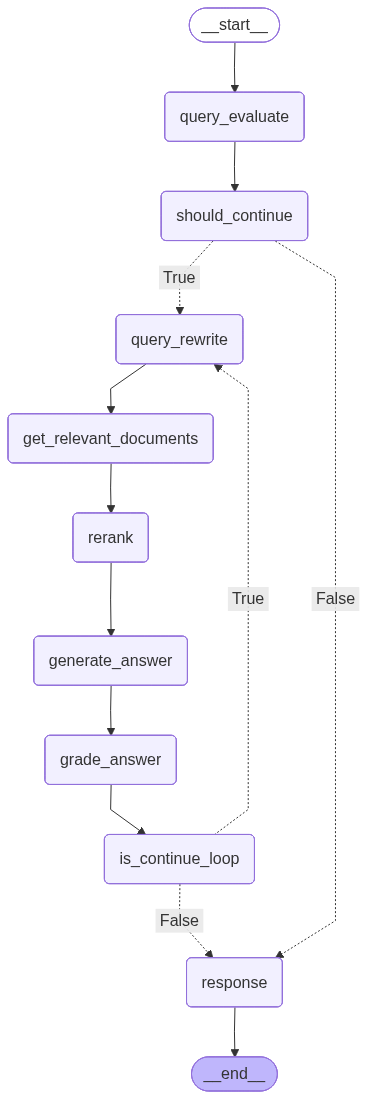

In [ ]:
workflow = StateGraph(ThreadState)

workflow.add_node("query_evaluate", query_evaluate)
workflow.add_node("should_continue", lambda x: x) # Dummy node
workflow.add_node("query_rewrite", query_rewrite)
workflow.add_node("get_relevant_documents", get_relevant_documents)
workflow.add_node("rerank", rerank)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("grade_answer", grade_answer)
workflow.add_node("response", response)
workflow.add_node("is_continue_loop", lambda x: x) # Dummy node


workflow.set_entry_point("query_evaluate")
workflow.add_edge("query_evaluate", "should_continue")

def should_continue(state: dict) -> bool:
  user_query_eval = state.get("user_query_grade")
  if user_query_eval and user_query_eval.is_lecture_related:
    return True
  return False

workflow.add_conditional_edges(
    "should_continue",
    should_continue,
    {False: "response", True: "query_rewrite"}
)

workflow.add_edge("query_rewrite", "get_relevant_documents")
workflow.add_edge("get_relevant_documents", "rerank")
workflow.add_edge("rerank", "generate_answer")
workflow.add_edge("generate_answer", "grade_answer")
workflow.add_edge("grade_answer", "is_continue_loop")


def is_continue_loop(state: dict) -> bool:
  response_grade = state.get("last_response_grade")
  n_iters = state.get("n_iterations", 1)
  if n_iters >= MAX_ITERS or (response_grade and response_grade.is_relevant):
    print(f"--End loop - n_iter: {n_iters}/{MAX_ITERS} - Is relevant: {response_grade.is_relevant if response_grade else 'N/A'}--")
    return False

  print(f"--Not relevant, continue loop!--")
  return True

workflow.add_conditional_edges(
    "is_continue_loop",
    is_continue_loop,
    {False: "response", True: "query_rewrite"}
)

workflow.add_edge("response", END)

rag_agent = workflow.compile()
display(Image(rag_agent.get_graph().draw_mermaid_png()))

In [ ]:
inital_state = {
  "user_query": " Vấn đề khi hàm mất mát có nhiều điểm cực tiểu và giải pháp?",
  "last_retrieved_docs": []
}

In [ ]:
res = rag_agent.invoke(inital_state)

--FUNCTION CALLED: QUERY EVALUATE--iter: 1
Query Eval: True
Reasoning: The query asks about 'loss functions', 'local minima', and 'solutions', which are core academic concepts in machine learning and optimization, likely covered in a lecture on these topics.
Suggestion: Chào bạn, mình sẽ tìm kiếm thông tin về 'hàm mất mát có nhiều điểm cực tiểu và giải pháp' trong tài liệu bài giảng nhé.
--FUNCTION CALLED: QUERY REWRITE--iter: 1
--FUNCTION CALLED: RETRIEVER--iter: 1
--Found 30 relevant documents--
--FUNCTION CALLED: RERANK--iter: 1
--FUNCTION CALLED: GENERATE ANSWER--iter: 1
--FUNCTION CALLED: ANSWER GRADE--iter: 1
Rel: True
Reasoning: The response directly addresses the user's query about the problem of multiple local minima in the loss function and provides two relevant solutions based on the lecture material: running the algorithm multiple times with different initializations and using momentum (specifically mentioning Adam as an example). It explains how each solution works and the

In [ ]:
Markdown(res['messages'][-1])

Khi hàm mất mát (cost function) có nhiều điểm cực tiểu (local minima), thuật toán Gradient Descent có thể dừng lại tại một điểm cực tiểu cục bộ thay vì tìm ra điểm cực tiểu toàn cục (global minimum) tối ưu nhất. Dựa trên nội dung bài giảng, có hai giải pháp chính để xử lý vấn đề này:

*   **Chạy nhiều lần và chọn giá trị nhỏ nhất:**
    *   Khởi tạo thuật toán Gradient Descent với nhiều giá trị **theta0** khác nhau.
    *   Thực hiện chạy thuật toán cho từng lần khởi tạo.
    *   Cuối cùng, lựa chọn kết quả có giá trị hàm loss nhỏ nhất trong số các lần chạy.
    *   **Nhược điểm:** Phương pháp này đòi hỏi tốn kém tài nguyên tính toán do phải lặp lại quá trình khởi tạo và tối ưu nhiều lần.

*   **Sử dụng Momentum (Quán tính) khi cập nhật tham số:**
    *   Khi thuật toán tiến gần đến một điểm cực tiểu cục bộ, **quán tính** sẽ giúp nó "vượt qua" điểm đó và tiếp tục di chuyển để tìm đến điểm cực tiểu toàn cục.
    *   Thuật toán **Adam** là một ví dụ điển hình, được cài đặt sẵn trong các framework học sâu như TensorFlow và PyTorch, giúp khai thác hiệu quả yếu tố quán tính này. Thuật toán Adam được coi là một giải pháp "mẹo" hữu ích khi cần tìm tham số **theta** để hàm loss **L(theta)** đạt giá trị nhỏ nhất.

In [ ]:
print("Videos Refernece:\n")
for i in res['last_retrieved_docs']:
  metadata = i.metadata
  id = i.id
  print(f"[{metadata['video_name']}]#{metadata['timestamp']} : id: {id}")

Videos Refernece:

[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#500 : id: 6abd9666-a700-482a-9c25-ae7c449a56ea
[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#760 : id: 3e1162f9-fa7d-4086-a2a4-a4a061362c42
[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#440 : id: ce69490a-ad73-4004-9b24-6fdc61dfa8a9
[[CS431 - Chương 7] Part 3_2_ Một số vấn đề của mạng RNN]#620 : id: ed7d8044-9194-4b22-b511-5aa9c242c600
[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#520 : id: 52cb95c2-e3db-4211-bd7c-8bc93993cdc4
[[CS431 - Chương 2] Part 3a_ Mô hình hồi quy luận lý (Logistic Regression)]#20 : id: 39e96333-942c-4255-82de-04b528fb5d2a
[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#880 : id: 33afe367-6c5c-434f-a183-04f83dab2a21
[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#580 : id: 6b2c6766-b99e-4ea8-8906-ba380fdf6b48
[[CS431 - Chương 7] Part 3_2_ Một số vấn đề của mạng RNN]#420 : id: aff4d983-fa30-430

In [ ]:
set([f"[{i.metadata['video_name']}]#{i.metadata['timestamp']}" for i in res['last_retrieved_docs']])

{'[[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.4.1 Ôn tập nền tảng giải tích (Part 1)]#40',
 '[[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.4.1 Ôn tập nền tảng giải tích (Part 1)]#420',
 '[[CS431 - Các kĩ thuật học sâu và ứng dụng] Video 1.4.1 Ôn tập nền tảng giải tích (Part 1)]#80',
 '[[CS431 - Chương 10] Part 4_2_ Kiến trúc Transformer_ Bộ Encoder]#320',
 '[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#220',
 '[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#420',
 '[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#440',
 '[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#500',
 '[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#520',
 '[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#580',
 '[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#760',
 '[[CS431 - Chương 2] Part 1_ Mô hình học tổng quát]#880',
 '[[CS431 - Chương 2] Part 3a

In [ ]:
len(res['last_retrieved_docs'])

20

In [ ]:
inital_state = {
  "user_query": "Hôm nay ăn gì?",
  "last_retrieved_docs": []
}

In [ ]:
res = rag_agent.invoke(inital_state)

--FUNCTION CALLED: QUERY EVALUATE--iter: 1
Query Eval: False
Reasoning: The query 'Hôm nay ăn gì?' (What to eat today?) is a casual, everyday question and does not pertain to any academic content, concepts, or logistics of the lecture.
Suggestion: Xin lỗi, tôi chỉ có thể trả lời các câu hỏi liên quan đến nội dung bài giảng. Bạn có câu hỏi nào về bài học không?
--FUNCTION CALLED: RESPONSE--iter: 1


In [ ]:
Markdown(res['messages'][-1])

Xin lỗi, tôi chỉ có thể trả lời các câu hỏi liên quan đến nội dung bài giảng. Bạn có câu hỏi nào về bài học không?